# **ЛАБОРАТОРНА РОБОТА 2b**
## Multi Layer Perceptron (MLP)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from time import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## **1. Завантаження та підготовка даних**
### Посилання на набір даних [https://www.kaggle.com/datasets/muratkokludataset/dry-bean-dataset](https://www.kaggle.com/datasets/muratkokludataset/dry-bean-dataset)

In [2]:
df = pd.read_csv("Dry_Bean_Dataset.csv")
print("Розмір датасету:", df.shape)

df

Розмір датасету: (13611, 17)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13606,42097,759.696,288.721612,185.944705,1.552728,0.765002,42508,231.515799,0.714574,0.990331,0.916603,0.801865,0.006858,0.001749,0.642988,0.998385,DERMASON
13607,42101,757.499,281.576392,190.713136,1.476439,0.735702,42494,231.526798,0.799943,0.990752,0.922015,0.822252,0.006688,0.001886,0.676099,0.998219,DERMASON
13608,42139,759.321,281.539928,191.187979,1.472582,0.734065,42569,231.631261,0.729932,0.989899,0.918424,0.822730,0.006681,0.001888,0.676884,0.996767,DERMASON
13609,42147,763.779,283.382636,190.275731,1.489326,0.741055,42667,231.653248,0.705389,0.987813,0.907906,0.817457,0.006724,0.001852,0.668237,0.995222,DERMASON


In [3]:
print("\nКількість пропущених значень:")
print(df.isnull().sum().sum())


Кількість пропущених значень:
0


In [4]:
print("Кількість дублікатів:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)
print("Розмір після видалення дублікатів:", df.shape)

Кількість дублікатів:

 68
Розмір після видалення дублікатів: (13543, 17)


In [5]:
print("Кількість об'єктів:", df.shape[0])

print("Кількість ознак:", df.shape[1] - 1)

print("Кількість класів:", df["Class"].nunique())
print(df["Class"].unique())

Кількість об'єктів: 13543
Кількість ознак: 16
Кількість класів: 7
['SEKER' 'BARBUNYA' 'BOMBAY' 'CALI' 'HOROZ' 'SIRA' 'DERMASON']


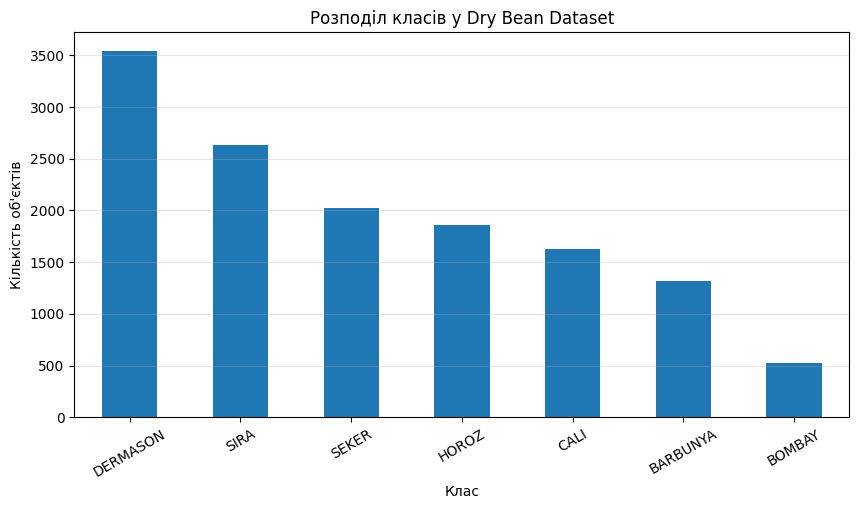

In [6]:
plt.figure(figsize=(10, 5))

df["Class"].value_counts().plot(kind="bar")

plt.xlabel("Клас")
plt.ylabel("Кількість об'єктів")
plt.title("Розподіл класів у Dry Bean Dataset")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)

plt.show()

### Кореляційний аналіз

In [7]:
# Check if the Class column is not numeric
if not np.issubdtype(df["Class"].dtype, np.number): 
 
    # Create a mapping for class names
    class_mapping = { 
        "SEKER": 0, 
        "BARBUNYA": 1, 
        "BOMBAY": 2, 
        "CALI": 3, 
        "DERMASON": 4, 
        "HOROZ": 5, 
        "SIRA": 6 
    } 
 
    # Convert class names to numbers
    df["Class_numeric"] = df["Class"].map(class_mapping) 
 
else: 
    
    # Use the class values as they are
    df["Class_numeric"] = df["Class"]

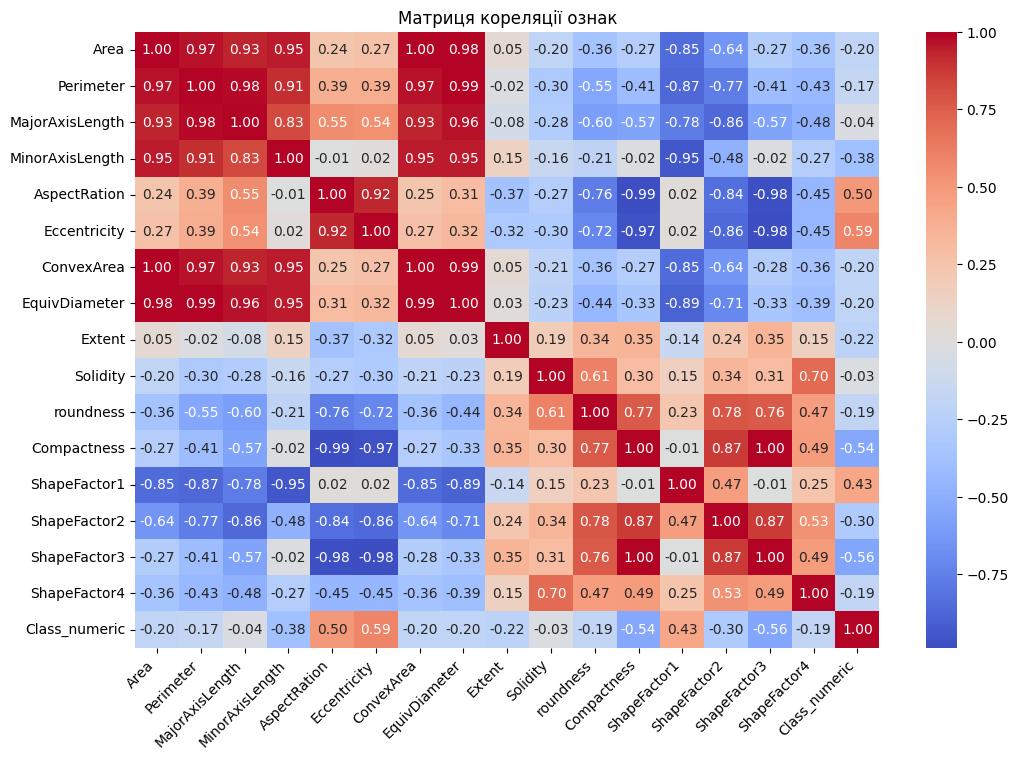

In [8]:
# Calculate the correlation matrix
correlation_matrix = df.drop(columns=["Class"]).corr()

plt.figure(figsize=(12, 8))

# Show the correlation matrix as a heatmap
sns.heatmap( correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0 )
plt.title("Матриця кореляції ознак")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()

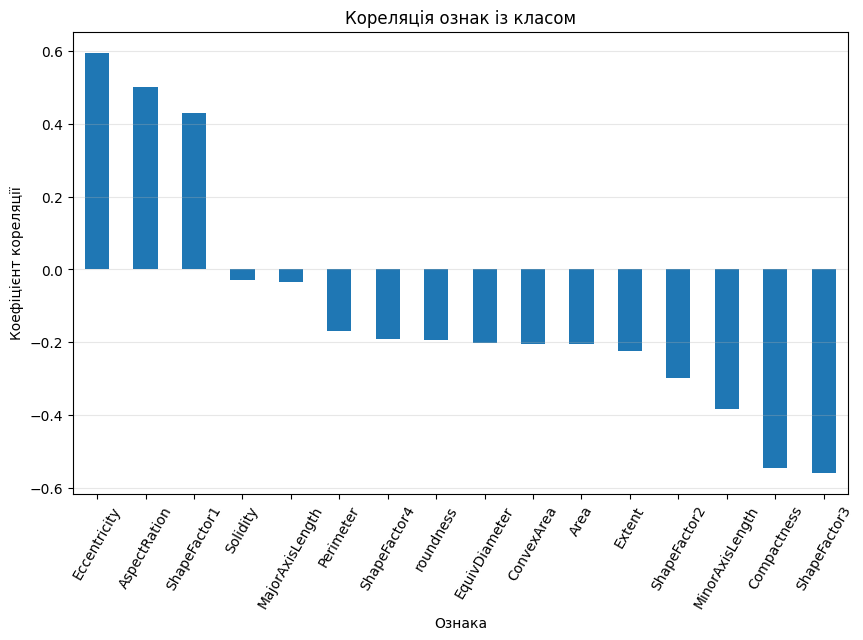

In [9]:
# Calculate correlation with the class
class_correlation = df.drop(columns=["Class"]).corr()["Class_numeric"].sort_values(ascending=False)

plt.figure(figsize=(10, 6))

# Create a bar chart
class_correlation.drop("Class_numeric").plot(kind="bar") 

plt.xlabel("Ознака")
plt.ylabel("Коефіцієнт кореляції")
plt.title("Кореляція ознак із класом")
plt.xticks(rotation=60)
plt.grid(axis="y", alpha=0.3)
plt.show()

### Візуалізація залежностей ознак від класу

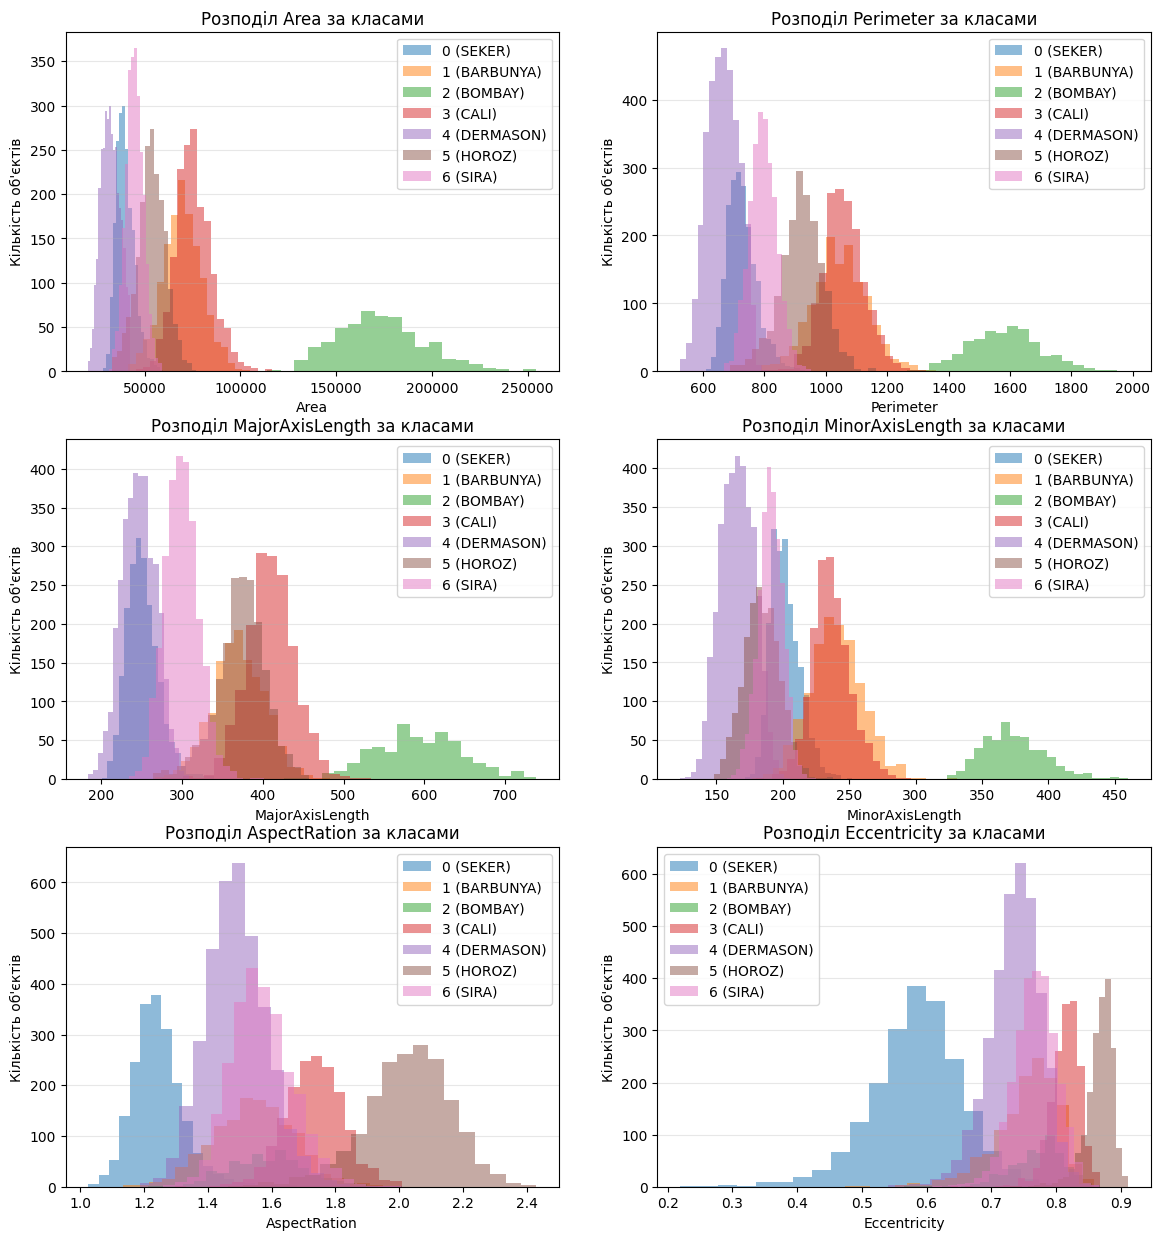

In [ ]:
# Select features for the histograms
features_to_plot = ["Area", "Perimeter", "MajorAxisLength", "MinorAxisLength", "AspectRation", "Eccentricity"]

# Create mapping from numbers to class names
class_mapping = {0: "SEKER", 1: "BARBUNYA", 2: "BOMBAY", 3: "CALI", 4: "DERMASON", 5: "HOROZ", 6: "SIRA"}

# Create a 3x2 grid of plots
fig, axes = plt.subplots(3, 2, figsize=(14, 15))

# Go through all features
for ax, feature in zip(axes.ravel(), features_to_plot):

    # Go through all classes
    for class_number, class_name in class_mapping.items():

        # Plot the histogram for the current class
        ax.hist(
            df[df["Class_numeric"] == class_number][feature],
            bins=20,
            alpha=0.5,
            label=f"{class_number} ({class_name})"
        )

    ax.set_xlabel(feature)
    ax.set_ylabel("Кількість об'єктів")
    ax.set_title(f"Розподіл {feature} за класами")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

plt.show()

### Підготовка X та y

In [11]:
X = df.drop(columns=["Class", "Class_numeric"]).values

y = df["Class_numeric"].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (13543, 16)
y shape: (13543,)


### Розділення даних на навчальну та тестову вибірки

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("\nРозмір навчальної вибірки:", X_train.shape)
print("Розмір тестової вибірки:", X_test.shape)


Розмір навчальної вибірки: (9480, 16)
Розмір тестової вибірки: (4063, 16)


### Стандартизація ознак

In [13]:
# Create a scaler
scaler = StandardScaler()

# Scale the training data
X_train = scaler.fit_transform(X_train)

# Scale the test data
X_test = scaler.transform(X_test)

### Функції активації

In [14]:
def relu(x):

    # Return the maximum value between 0 and x
    return np.maximum(0, x)


def relu_derivative(x):

    # Return 1 for positive values and 0 otherwise
    return (x > 0).astype(float)


def sigmoid(x):

    # Limit values to avoid overflow
    x = np.clip(x, -500, 500)

    # Calculate sigmoid
    return 1 / (1 + np.exp(-x))

## **2. Реалізація багатошарового персептрона**

In [15]:
class MyMLP: 
 
    def __init__( 
        self, 
        input_size=16, 
        hidden1_size=16, 
        hidden2_size=8, 
        output_size=7, 
        learning_rate=0.01, 
        epochs=1000 
    ): 
 
        # Save model parameters
        self.input_size = input_size 
        self.hidden1_size = hidden1_size 
        self.hidden2_size = hidden2_size 
        self.output_size = output_size 
        self.learning_rate = learning_rate 
        self.epochs = epochs 
 
        # Save training results
        self.loss_history = [] 
        self.accuracy_history = [] 
 
        # Initialize weights for the first layer
        self.W1 = np.random.randn( 
            input_size, 
            hidden1_size 
        ) * np.sqrt(2 / input_size) 
 
        # Initialize bias for the first layer
        self.b1 = np.zeros((1, hidden1_size)) 
         
        # Initialize weights for the second layer
        self.W2 = np.random.randn( 
            hidden1_size, 
            hidden2_size 
        ) * np.sqrt(2 / hidden1_size) 
 
        # Initialize bias for the second layer
        self.b2 = np.zeros((1, hidden2_size)) 
 
        # Initialize weights for the output layer
        self.W3 = np.random.randn( 
            hidden2_size, 
            output_size 
        ) * np.sqrt(2 / hidden2_size) 
 
        # Initialize bias for the output layer
        self.b3 = np.zeros((1, output_size)) 
 
 
    def softmax(self, Z): 
 
        # Make values more stable
        Z = Z - np.max(Z, axis=1, keepdims=True) 
        
        # Calculate exponential values
        exp_Z = np.exp(Z) 
 
        # Convert values to probabilities
        return exp_Z / np.sum( 
            exp_Z, 
            axis=1, 
            keepdims=True 
        ) 
 
 
    def forward(self, X): 
 
        # Calculate the first layer
        self.Z1 = X @ self.W1 + self.b1 
        
        # Apply ReLU activation
        self.A1 = relu(self.Z1) 
 
        # Calculate the second layer
        self.Z2 = self.A1 @ self.W2 + self.b2 
        
        # Apply ReLU activation
        self.A2 = relu(self.Z2) 
 
        # Calculate the output layer
        self.Z3 = self.A2 @ self.W3 + self.b3 
        
        # Convert output to probabilities
        self.A3 = self.softmax(self.Z3) 
 
        return self.A3 
 
 
    def loss(self, y, y_pred): 
 
        # Get the number of samples
        m = y.shape[0] 
        
        # Convert labels to integers
        y = y.astype(int) 
 
        # Get probabilities of correct classes
        correct_class_probabilities = y_pred[ np.arange(m), y ] 
        
        # Avoid log(0)
        correct_class_probabilities = np.clip( correct_class_probabilities, 1e-10, 1.0) 
 
        # Calculate cross-entropy loss
        return -np.mean( np.log(correct_class_probabilities)) 
 
 
    def backward(self, X, y, y_pred): 
 
        # Get the number of samples
        m = X.shape[0] 
        
        # Convert labels to integers
        y = y.astype(int) 
         
        # Calculate output error
        dZ3 = y_pred.copy() 
        
        # Subtract 1 from the correct class
        dZ3[ np.arange(m), y] -= 1 
        
        # Average the error
        dZ3 /= m 
         
        # Calculate gradient for W3
        dW3 = self.A2.T @ dZ3 
         
        # Calculate gradient for b3
        db3 = np.sum( dZ3, axis=0, keepdims=True) 
         
        # Move error to the second layer
        dA2 = dZ3 @ self.W3.T 
         
        # Apply ReLU derivative
        dZ2 = dA2 * relu_derivative(self.Z2) 
         
        # Calculate gradient for W2
        dW2 = self.A1.T @ dZ2 
         
        # Calculate gradient for b2
        db2 = np.sum(dZ2, axis=0, keepdims=True ) 
 
        # Move error to the first layer
        dA1 = dZ2 @ self.W2.T 
        
        # Apply ReLU derivative
        dZ1 = dA1 * relu_derivative(self.Z1) 
 
        # Calculate gradient for W1
        dW1 = X.T @ dZ1 
        
        # Calculate gradient for b1
        db1 = np.sum( dZ1, axis=0, keepdims=True) 
 
        # Update weights and biases
        self.W3 -= self.learning_rate * dW3 
        self.b3 -= self.learning_rate * db3 
 
        self.W2 -= self.learning_rate * dW2 
        self.b2 -= self.learning_rate * db2 
 
        self.W1 -= self.learning_rate * dW1 
        self.b1 -= self.learning_rate * db1 
 
 
    def fit(self, X, y): 
 
        # Clear old training results
        self.loss_history = [] 
        self.accuracy_history = [] 
 
        # Start training
        for epoch in range(self.epochs): 
 
            # Make predictions
            y_pred = self.forward(X) 
            
            # Calculate loss
            current_loss = self.loss( y, y_pred ) 
            
            # Update model weights
            self.backward( X, y, y_pred) 
            
            # Get predicted classes
            predictions = np.argmax(y_pred, axis=1) 
            
            # Calculate accuracy
            accuracy = np.mean(predictions == y) 
            
            # Save results
            self.loss_history.append(current_loss) 
            self.accuracy_history.append(accuracy) 
 
            # Print results every 100 epochs
            if (epoch + 1) % 100 == 0: 
                print( 
                    f"Epoch {epoch + 1}/{self.epochs}, " 
                    f"Loss: {current_loss:.6f}, " 
                    f"Accuracy: {accuracy:.4f}" 
                ) 
        
        return self 
 
 
    def predict_proba(self, X): 
        
        # Return class probabilities
        return self.forward(X) 
 
 
    def predict(self, X): 
        
        # Get class probabilities
        probabilities = self.predict_proba(X) 
        
        # Return the class with the highest probability
        return np.argmax(probabilities, axis=1 )

In [16]:
np.random.seed(42)

my_mlp = MyMLP(
    input_size=X_train.shape[1],
    hidden1_size=16,
    hidden2_size=8,
    output_size=7,
    learning_rate=0.01,
    epochs=2000
)

start_time = time()
my_mlp.fit(X_train, y_train)
my_runtime = time() - start_time

Epoch 100/2000, Loss: 1.483800, Accuracy: 0.4810
Epoch 200/2000, Loss: 1.201733, Accuracy: 0.5630
Epoch 300/2000, Loss: 1.046574, Accuracy: 0.6329
Epoch 400/2000, Loss: 0.925804, Accuracy: 0.7003
Epoch 500/2000, Loss: 0.825002, Accuracy: 0.7507
Epoch 600/2000, Loss: 0.734075, Accuracy: 0.7918
Epoch 700/2000, Loss: 0.630575, Accuracy: 0.8254
Epoch 800/2000, Loss: 0.544298, Accuracy: 0.8451
Epoch 900/2000, Loss: 0.482586, Accuracy: 0.8565
Epoch 1000/2000, Loss: 0.441487, Accuracy: 0.8696
Epoch 1100/2000, Loss: 0.412194, Accuracy: 0.8790
Epoch 1200/2000, Loss: 0.390004, Accuracy: 0.8862
Epoch 1300/2000, Loss: 0.372317, Accuracy: 0.8918
Epoch 1400/2000, Loss: 0.357735, Accuracy: 0.8950
Epoch 1500/2000, Loss: 0.345464, Accuracy: 0.8976
Epoch 1600/2000, Loss: 0.334900, Accuracy: 0.8999
Epoch 1700/2000, Loss: 0.325652, Accuracy: 0.9016
Epoch 1800/2000, Loss: 0.317462, Accuracy: 0.9042
Epoch 1900/2000, Loss: 0.310167, Accuracy: 0.9068
Epoch 2000/2000, Loss: 0.303560, Accuracy: 0.9080


In [ ]:
# Predict classes for the training data
y_train_pred = my_mlp.predict(X_train)

# Predict classes for the test data
y_test_pred = my_mlp.predict(X_test)

# Calculate training accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)

# Calculate test accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy:  {test_accuracy:.4f}")
print(f"Time:        {my_runtime:.4f} s")


Train Accuracy: 0.9080
Test Accuracy:  0.9030
Time:        30.1815 s


## **3. Реалізація багатошарового песпетрона за допомогою бібліотеки Scikit-learn**

In [18]:
sklearn_mlp = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation="relu",
    solver="adam",
    learning_rate_init=0.01,
    max_iter=1000,
    random_state=42
)

start_time = time()
sklearn_mlp.fit(X_train, y_train)
sklearn_runtime = time() - start_time

In [ ]:
# Predict classes for the training data
y_train_pred_sklearn = sklearn_mlp.predict(X_train)

# Predict classes for the test data
y_test_pred_sklearn = sklearn_mlp.predict(X_test)

# Calculate training accuracy
train_accuracy_sklearn = accuracy_score(y_train, y_train_pred_sklearn)

# Calculate test accuracy
test_accuracy_sklearn = accuracy_score(y_test, y_test_pred_sklearn)

print(f"Train Accuracy: {train_accuracy_sklearn:.4f}")
print(f"Test Accuracy:  {test_accuracy_sklearn:.4f}")
print(f"Time:        {sklearn_runtime:.4f} s")

Train Accuracy: 0.9350
Test Accuracy:  0.9239
Time:        2.9306 s


## **4. Порівняння**

In [20]:
comparison = pd.DataFrame({
    "Model": [
        "Власний MLP",
        "Scikit-learn MLP"
    ],
    "Train Accuracy": [
        train_accuracy,
        train_accuracy_sklearn
    ],
    "Test Accuracy": [
        test_accuracy,
        test_accuracy_sklearn
    ],
    "Time": [
        my_runtime,
        sklearn_runtime
    ]
})

print(comparison)

              Model  Train Accuracy  Test Accuracy       Time
0       Власний MLP        0.908017       0.903027  30.181495
1  Scikit-learn MLP        0.935021       0.923948   2.930578


### Порівняння функцій втрат

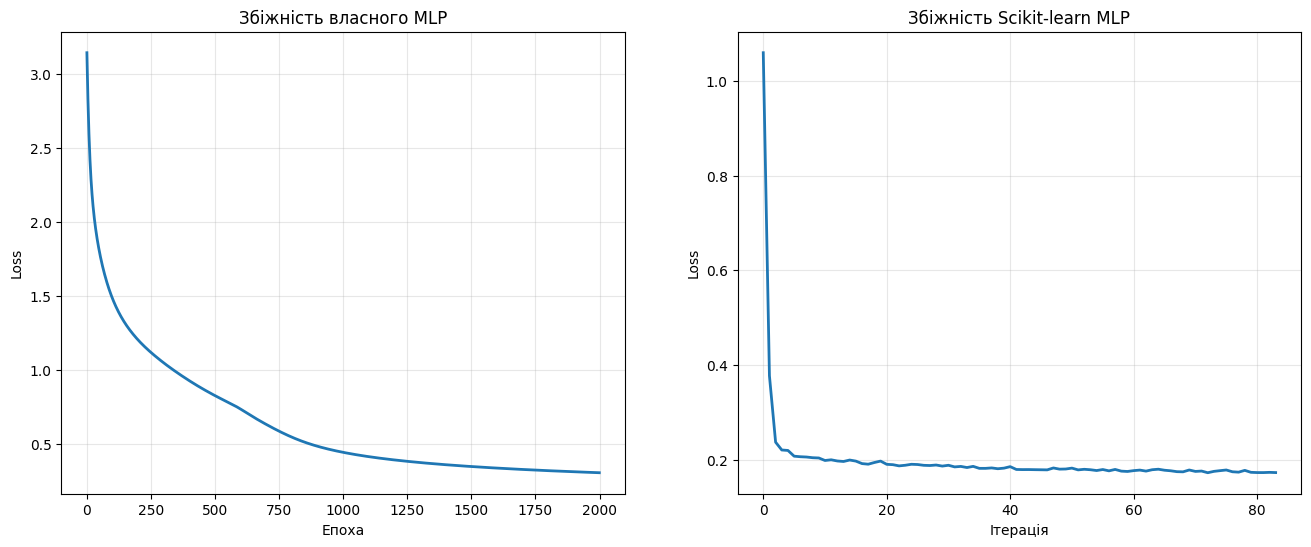

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(my_mlp.loss_history, linewidth=2)
axes[0].set_xlabel("Епоха")
axes[0].set_ylabel("Loss")
axes[0].set_title("Збіжність власного MLP")
axes[0].grid(True, alpha=0.3)

axes[1].plot(sklearn_mlp.loss_curve_, linewidth=2)
axes[1].set_xlabel("Ітерація")
axes[1].set_ylabel("Loss")
axes[1].set_title("Збіжність Scikit-learn MLP")
axes[1].grid(True, alpha=0.3)

plt.show()

### Порівняння матриць помилок

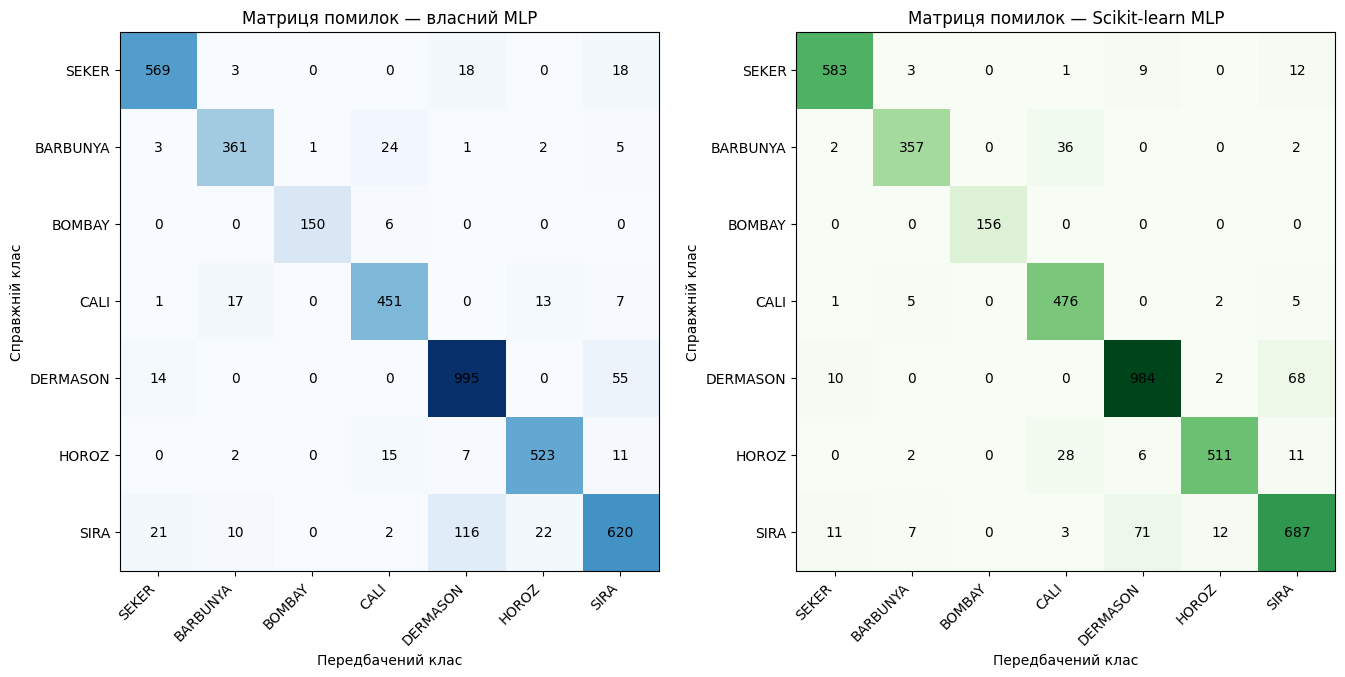

In [22]:
cm_my = confusion_matrix(y_test, y_test_pred)
cm_sklearn = confusion_matrix( y_test, y_test_pred_sklearn)

class_names = [
    "SEKER",
    "BARBUNYA",
    "BOMBAY",
    "CALI",
    "DERMASON",
    "HOROZ",
    "SIRA"
]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].imshow(cm_my, cmap="Blues")
axes[0].set_title("Матриця помилок — власний MLP")
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(class_names, rotation=45, ha="right")
axes[0].set_yticks(range(7))
axes[0].set_yticklabels(class_names)
axes[0].set_xlabel("Передбачений клас")
axes[0].set_ylabel("Справжній клас")

for i in range(7):
    for j in range(7):
        axes[0].text(
            j,
            i,
            cm_my[i, j],
            ha="center",
            va="center"
        )

axes[0].grid(False)


axes[1].imshow(cm_sklearn, cmap="Greens")
axes[1].set_title("Матриця помилок — Scikit-learn MLP")
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(class_names, rotation=45, ha="right")
axes[1].set_yticks(range(7))
axes[1].set_yticklabels(class_names)
axes[1].set_xlabel("Передбачений клас")
axes[1].set_ylabel("Справжній клас")

for i in range(7):
    for j in range(7):
        axes[1].text(
            j,
            i,
            cm_sklearn[i, j],
            ha="center",
            va="center"
        )

axes[1].grid(False)
plt.show()

### Графік порівняння точності

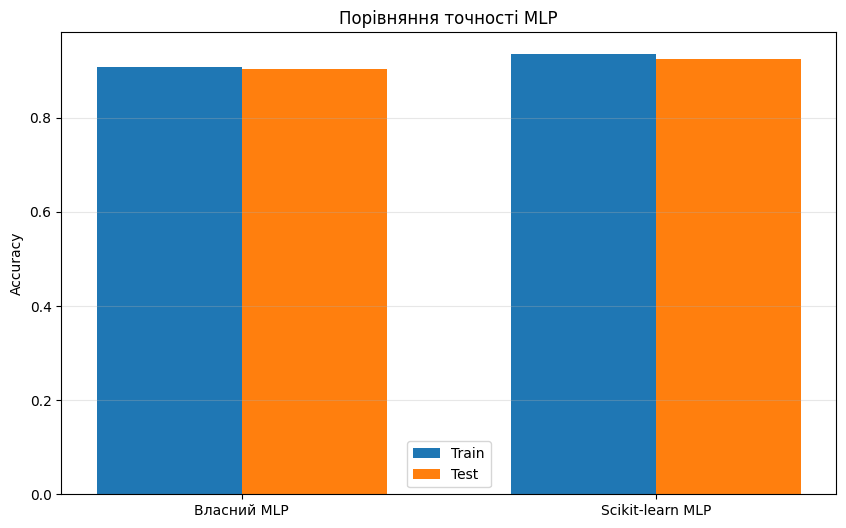

In [23]:
x = np.arange(len(comparison))

plt.figure(figsize=(10, 6))
plt.bar(x - 0.35 / 2, comparison["Train Accuracy"], 0.35, label="Train")
plt.bar(x + 0.35 / 2, comparison["Test Accuracy"], 0.35, label="Test")
plt.xticks(x, comparison["Model"])
plt.ylabel("Accuracy")
plt.title("Порівняння точності MLP")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

### Графік порівняння часу виконання

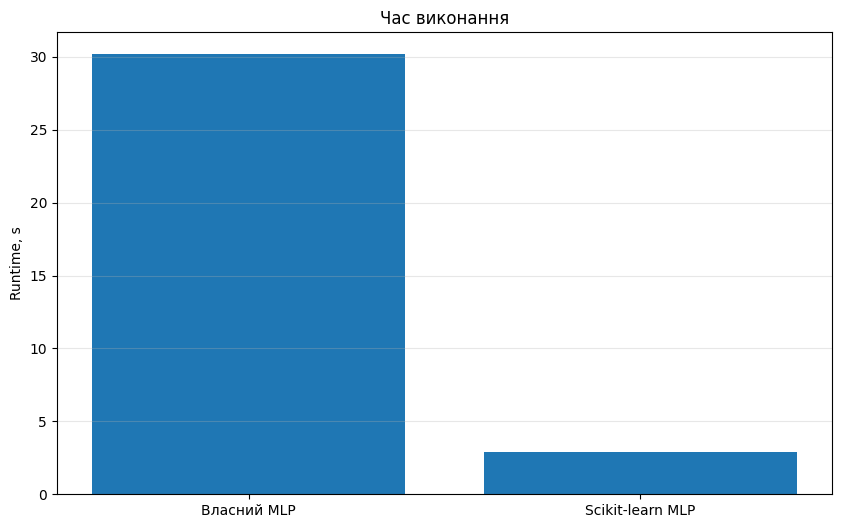

In [24]:
plt.figure(figsize=(10, 6))
plt.bar(comparison["Model"], comparison["Time"])
plt.ylabel("Runtime, s")
plt.title("Час виконання")
plt.grid(axis="y", alpha=0.3)
plt.show()